# 04. Final Coloring Book Pipeline

이 노트북은 전체 시스템을 하나로 연결합니다.

입력:

- 사용자 이미지 경로
- 원하는 색상 개수 K
- 경계선 Canny 임계값
- 선 두께
- 최소 영역 크기

출력:

1. 원본 이미지
2. K-Means 결과
3. Posterization 결과
4. Sobel 결과
5. Laplacian 결과
6. Canny 결과
7. 영역 분리 결과
8. 색상 번호가 들어간 최종 컬러링북 이미지
9. RGB 색상표
10. 성능 비교 표

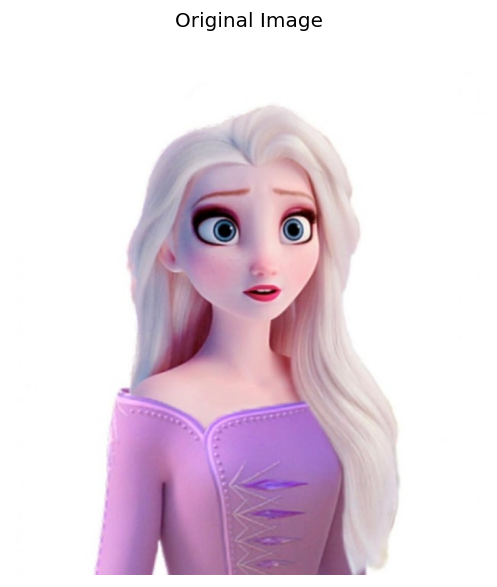

In [1]:
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

# 공통 함수가 들어 있는 src 폴더를 import 경로에 추가합니다.
sys.path.append("src")
from coloringbook_utils import *

# 결과 저장 폴더(outputs)와 샘플 입력 폴더(data)를 생성합니다.
ensure_dirs()
plt.rcParams["figure.dpi"] = 120

# 직접 사용할 이미지가 있으면 여기에 경로를 넣으세요.
# 예: IMAGE_PATH = "data/elsa.jpeg"
IMAGE_PATH = "data/elsa.jpeg"

# IMAGE_PATH가 None이면 발표/실험용 샘플 이미지가 자동 생성됩니다.
image = load_image(IMAGE_PATH)
show_images([("Original Image", image)], cols=1, figsize=(5, 5))

## 전체 파라미터

실험 발표에서는 `K=5, 10, 20`을 비교하고, 최종 결과는 보통 `K=10`부터 조정하는 방식이 좋습니다.

In [2]:
# 최종 결과의 기본 색상 수입니다. 보고서에서는 K=5, 10, 20 비교도 함께 사용합니다.
K = 10

# Canny 임계값입니다. 값이 높으면 노이즈는 줄지만 필요한 경계가 사라질 수 있습니다.
CANNY_LOW = 60
CANNY_HIGH = 150

# 선 두께가 두꺼울수록 인쇄 가독성은 좋아지고 색칠 공간은 줄어듭니다.
LINE_THICKNESS = 2

# 너무 작은 영역은 번호가 읽기 어렵기 때문에 제거합니다.
MIN_REGION_AREA = 160

## 최종 파이프라인 실행

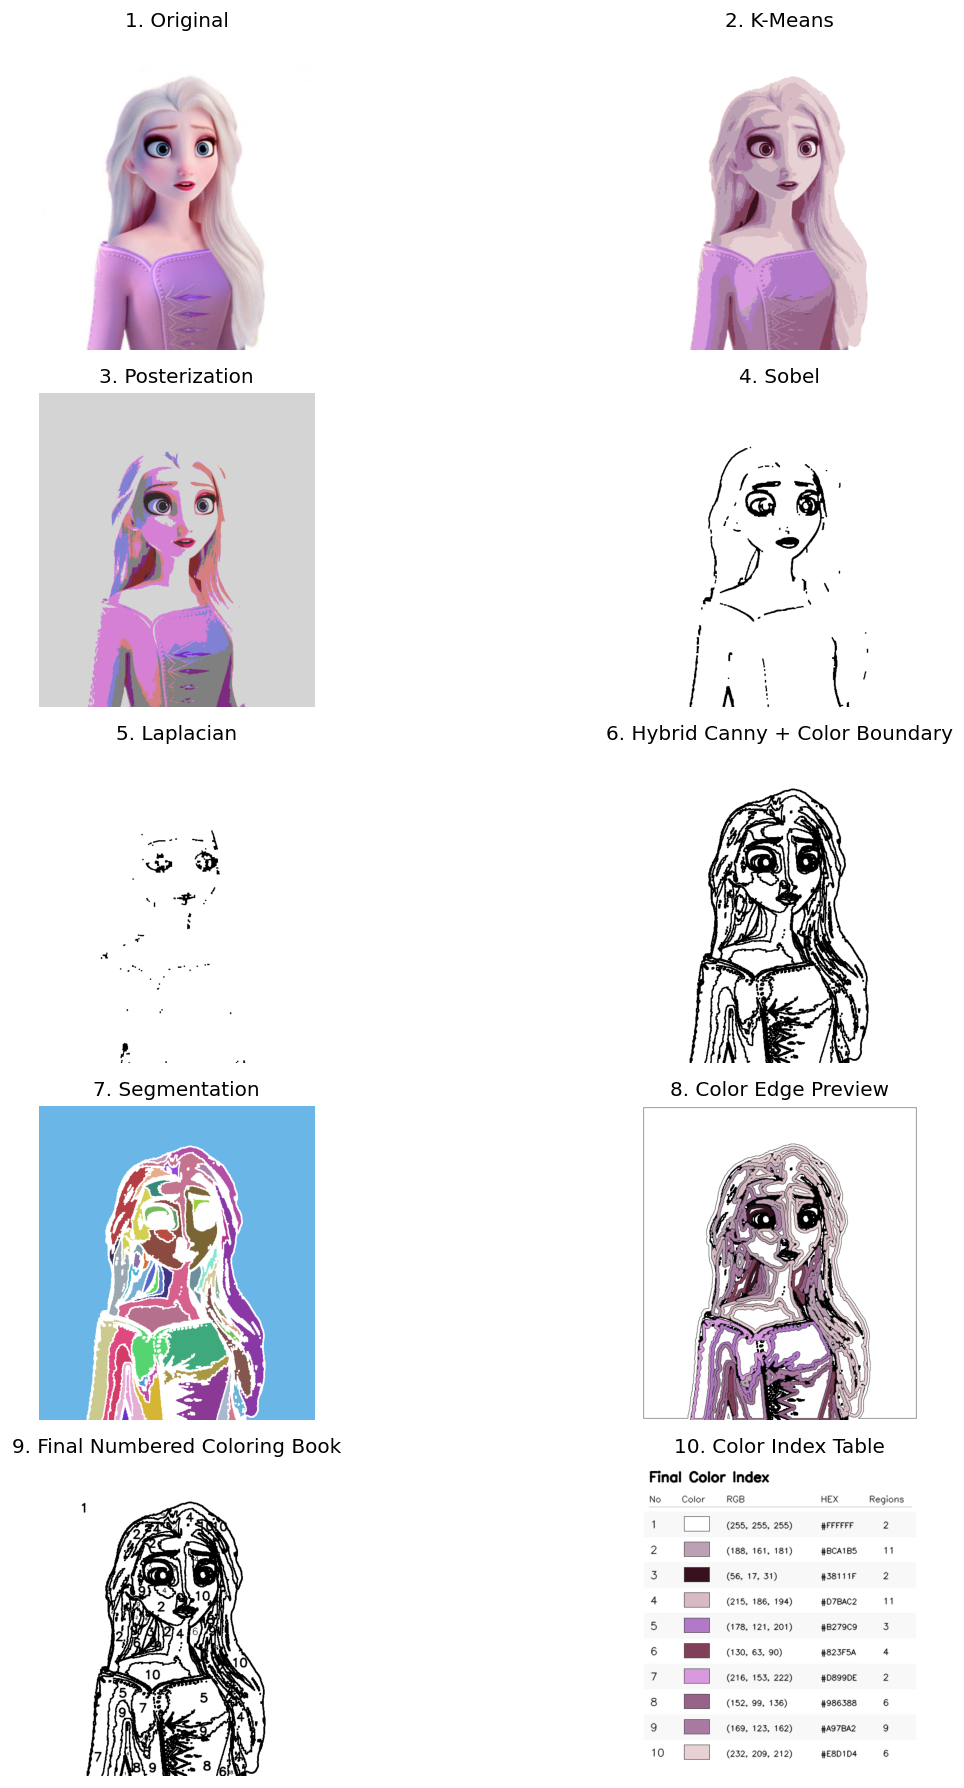

In [3]:
# 1. 색상 단순화: 최종 기본 알고리즘은 K-Means입니다.
(kmeans_img, kmeans_palette, kmeans_labels), kmeans_time = timed_call(kmeans_quantization_with_labels, image, K)

# Posterization은 속도 비교용 보조 알고리즘입니다.
(poster_img, poster_palette), poster_time = timed_call(posterization, image, K)

# 2. 경계선 추출 알고리즘 비교: 여러 알고리즘을 같은 입력에서 비교합니다.
(sobel_raw, sobel_time) = timed_call(sobel_edges, kmeans_img, 65)
(lap_raw, lap_time) = timed_call(laplacian_edges, kmeans_img, 25)
(canny_raw, canny_time) = timed_call(canny_edges, kmeans_img, CANNY_LOW, CANNY_HIGH)
(hybrid_raw, hybrid_time) = timed_call(hybrid_canny_color_edges, kmeans_img, CANNY_LOW, CANNY_HIGH, kmeans_labels)

# 흰 배경 + 검은 선 형태로 바꿔 컬러링북 출력 형식에 맞춥니다.
sobel_line = coloring_line_image(clean_edges(sobel_raw, open_iter=1, close_iter=1, thickness=1))
lap_line = coloring_line_image(clean_edges(lap_raw, open_iter=1, close_iter=1, thickness=1))
canny_edges_clean = clean_edges(hybrid_raw, open_iter=0, close_iter=1, thickness=LINE_THICKNESS)
canny_line = coloring_line_image(canny_edges_clean)

# 3. 영역 분리 및 번호화: Connected Components로 흰 영역을 분리합니다.
(region_map, regions), seg_time = timed_call(segment_connected_components, canny_line, MIN_REGION_AREA)
background_color = estimate_background_color(kmeans_img)
regions = assign_region_color_numbers(
    regions,
    region_map,
    kmeans_labels,
    kmeans_palette,
    background_color=background_color,
    background_color_threshold=16,
    merge_background_similar=True,
)
numbered_regions = colorable_regions(regions)
region_preview = color_region_preview(region_map)
color_edge_preview = color_region_edge_preview(canny_line, region_map, regions, kmeans_palette, thickness=4)
numbered_coloringbook = label_regions(canny_line, regions, font_scale=0.9, region_map=region_map)
color_index = save_color_index_table(kmeans_palette, "flowersoutput/04_color_index_table.png", regions, "Final Color Index")
numbered_with_index = combine_with_color_index(
    numbered_coloringbook,
    kmeans_palette,
    regions,
    "flowersoutput/04_numbered_with_color_index.png",
    "Final Color Index",
)

# 4. 저장: 단계별 결과를 outputs 폴더에 저장합니다.
save_image_rgb("flowersoutput/04_original.png", image)
save_image_rgb("flowersoutput/04_kmeans.png", kmeans_img)
save_image_rgb("flowersoutput/04_posterization.png", poster_img)
save_image_rgb("flowersoutput/04_sobel.png", sobel_line)
save_image_rgb("flowersoutput/04_laplacian.png", lap_line)
save_image_rgb("flowersoutput/04_canny.png", canny_line)
save_image_rgb("flowersoutput/04_region_preview.png", region_preview)
save_image_rgb("flowersoutput/04_color_edge_preview.png", color_edge_preview)
save_image_rgb("flowersoutput/04_final_numbered_coloringbook.png", numbered_coloringbook)

show_images([
    ("1. Original", image),
    ("2. K-Means", kmeans_img),
    ("3. Posterization", poster_img),
    ("4. Sobel", sobel_line),
    ("5. Laplacian", lap_line),
    ("6. Hybrid Canny + Color Boundary", canny_line),
    ("7. Segmentation", region_preview),
    ("8. Color Edge Preview", color_edge_preview),
    ("9. Final Numbered Coloring Book", numbered_coloringbook),
    ("10. Color Index Table", color_index),
], cols=2, figsize=(13, 15), cmap="gray", save_path="flowersoutput/04_final_results_grid.png")

## RGB 색상표

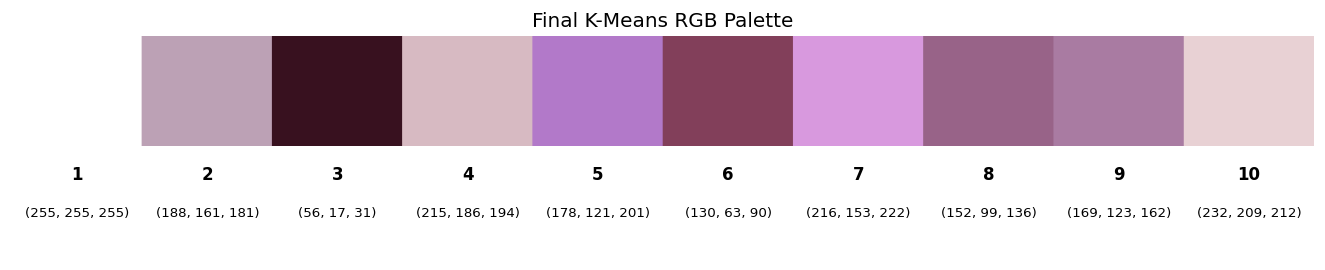

In [4]:
plot_palette(kmeans_palette, "Final K-Means RGB Palette", "flowersoutput/04_final_palette.png")

## 성능 비교 표

In [5]:
metrics = region_metrics(numbered_regions, image.shape, small_area=300)
performance_rows = [
    {"stage": "K-Means", "runtime_sec": kmeans_time, "edge_density": "", "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Posterization", "runtime_sec": poster_time, "edge_density": "", "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Sobel", "runtime_sec": sobel_time, "edge_density": edge_density(255 - sobel_line), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Laplacian", "runtime_sec": lap_time, "edge_density": edge_density(255 - lap_line), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Canny", "runtime_sec": canny_time, "edge_density": edge_density(canny_raw), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Hybrid Canny + Color Boundary", "runtime_sec": hybrid_time, "edge_density": edge_density(canny_edges_clean), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Segmentation", "runtime_sec": seg_time, "edge_density": "", "regions": metrics["regions"], "average_area": metrics["average_area"], "small_regions": metrics["small_regions"]},
    {"stage": "Background-like Regions", "runtime_sec": "", "edge_density": "", "regions": sum(1 for region in regions if region.get("is_background")), "average_area": "", "small_regions": ""},
    {"stage": "Total Final", "runtime_sec": kmeans_time + canny_time + seg_time, "edge_density": edge_density(canny_edges_clean), "regions": metrics["regions"], "average_area": metrics["average_area"], "small_regions": metrics["small_regions"]},
]
print_table(performance_rows)

stage                         | runtime_sec | edge_density | regions | average_area | small_regions
------------------------------+-------------+--------------+---------+--------------+--------------
K-Means                       | 0.5336      |              |         |              |              
Posterization                 | 0.4403      |              |         |              |              
Sobel                         | 0.0041      | 0.0337       |         |              |              
Laplacian                     | 0.0017      | 0.0089       |         |              |              
Canny                         | 0.0008      | 0.0139       |         |              |              
Hybrid Canny + Color Boundary | 0.0018      | 0.1720       |         |              |              
Segmentation                  | 0.0076      |              | 56      | 6387.6250    | 11           
Background-like Regions       |             |              | 2       |              |              


## 색상 개수별 복잡도 변화

K  | runtime_sec | edge_density | regions | average_area | small_regions
---+-------------+--------------+---------+--------------+--------------
5  | 0.3899      | 0.0590       | 30      | 13671.9333   | 5            
10 | 0.5156      | 0.0965       | 21      | 18633.6667   | 5            
20 | 0.7131      | 0.1262       | 38      | 9902.9474    | 10           


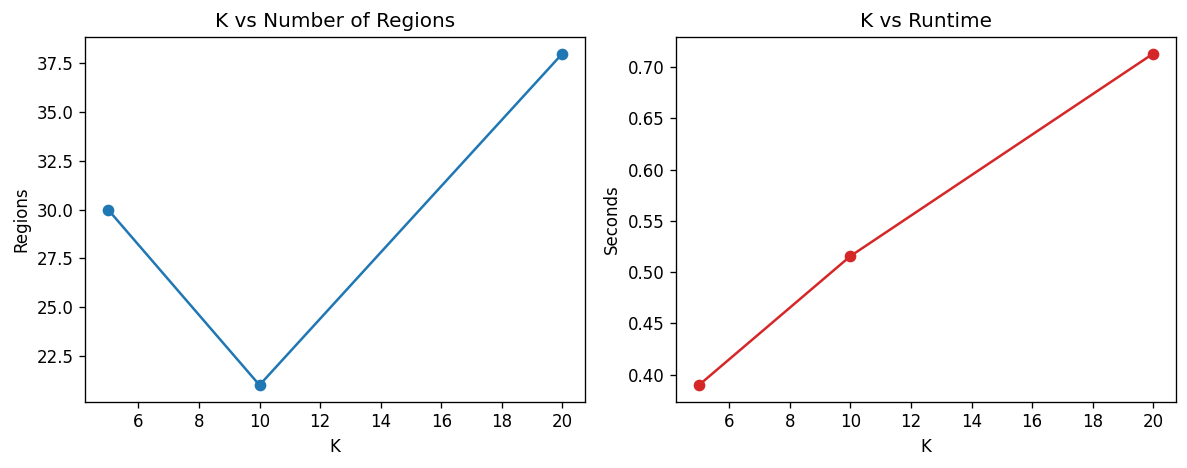

In [6]:
# K가 증가할수록 색상 표현력, 영역 수, 실행 시간이 어떻게 변하는지 측정합니다.
complexity_rows = complexity_by_k(image, k_values=(5, 10, 20), min_area=MIN_REGION_AREA)
print_table(complexity_rows)

ks = [row["K"] for row in complexity_rows]
regions_by_k = [row["regions"] for row in complexity_rows]
runtime_by_k = [row["runtime_sec"] for row in complexity_rows]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(ks, regions_by_k, marker="o")
axes[0].set_title("K vs Number of Regions")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Regions")
axes[1].plot(ks, runtime_by_k, marker="o", color="tab:red")
axes[1].set_title("K vs Runtime")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Seconds")
plt.tight_layout()
plt.savefig("flowersoutput/04_complexity_by_k.png", dpi=160, bbox_inches="tight")
plt.show()

## 자동 정리: 알고리즘 장단점

### 색상 단순화

- K-Means 장점: 이미지 색상 분포를 반영해 대표색을 찾으므로 색상 유지 품질이 좋습니다.
- K-Means 단점: 반복 계산이 필요해 Posterization보다 느립니다.
- Posterization 장점: 매우 빠르고 구현이 단순합니다.
- Posterization 단점: 실제 이미지 색상 분포와 무관하게 균등 분할하므로 부자연스러운 색상 계단이 생길 수 있습니다.
- Median Cut 장점: 색상 분포 범위를 재귀적으로 나누므로 교육용 설명과 비교 실험에 좋습니다.
- Median Cut 단점: 고품질 최적화는 K-Means보다 약하고 구현 방식에 따라 속도 차이가 큽니다.

### 경계선 추출

- Sobel 장점: 방향별 밝기 변화 설명이 쉽고 빠릅니다.
- Sobel 단점: 선이 두껍거나 질감 변화에 민감할 수 있습니다.
- Laplacian 장점: 모든 방향의 급격한 변화를 한 번에 감지합니다.
- Laplacian 단점: 노이즈와 작은 텍스처까지 경계로 잡는 경향이 있습니다.
- Canny 장점: 노이즈 제거와 이중 임계값을 포함해 선명하고 안정적인 경계를 제공합니다.
- Canny 단점: 밝기가 비슷한 서로 다른 색의 경계는 놓칠 수 있습니다.
- Hybrid Color Boundary 장점: Canny 결과에 색상 라벨 경계를 합쳐 겹친 색상 영역도 분리합니다.
- Hybrid Color Boundary 단점: K-Means 결과가 과분할되면 선이 많아져 복잡도가 올라갈 수 있습니다.

### 영역 분리

- Connected Components 장점: 닫힌 흰 영역을 직접 분리하고, 각 영역에 dominant 색상 번호를 넣기 쉬워 최종 산출물에 적합합니다.
- Connected Components 단점: 선이 끊기면 영역이 합쳐질 수 있어 Morphology 보정이 중요합니다.
- 배경 번호 병합 장점: 외곽에서 추정한 배경색과 비슷한 내부 빈 공간도 같은 배경 번호로 표시되어 색상표와 일관됩니다.
- Contour Detection 장점: 외곽선 시각화와 영역 형태 확인이 쉽습니다.
- Contour Detection 단점: 내부 계층 구조 처리가 필요할 수 있습니다.
- Watershed 장점: 겹친 객체 분리에 강합니다.
- Watershed 단점: 컬러링북에서는 과분할로 인해 사용자가 색칠하기 어려운 작은 영역이 늘 수 있습니다.

## 최종 알고리즘 선택 이유

최종 조합은 `K-Means + Hybrid Canny/Color Boundary + Connected Components/Contour Detection`입니다. K-Means는 원본 색상 보존과 색상 수 제어의 균형이 좋고, Hybrid 경계선은 밝기가 비슷한 색상 사이의 경계까지 보완하며, Connected Components는 색상 번호를 넣을 색칠 영역을 직접 계산하기 좋습니다.

## Trade-off 분석

- K 증가: 원본과 비슷해지지만 영역 수와 번호 수가 늘어 색칠 난이도가 올라갑니다.
- 선 두께 증가: 경계 가독성은 좋아지지만 색칠 공간이 줄고 작은 영역이 사라질 수 있습니다.
- 최소 영역 크기 증가: 번호 가독성은 좋아지지만 세부 묘사가 줄어듭니다.
- Canny 임계값 증가: 노이즈는 줄지만 필요한 경계가 누락될 수 있습니다.

## 발표용 비교 포인트

- 같은 이미지에서 K=5, 10, 20 결과를 나란히 보여주며 복잡도 변화를 설명합니다.
- Sobel, Laplacian, Canny의 Edge Density와 시각적 노이즈를 비교합니다.
- 영역 개수, 평균 영역 크기, 작은 영역 개수를 HCI 지표로 연결합니다.
- 최종 결과는 K-Means 색상표 번호와 영역 번호가 연결되므로, 같은 색상 영역은 같은 숫자로 칠할 수 있습니다.

## HCI 관점 개선점

- 색상 단순화로 사용자가 선택해야 할 색의 수를 줄였습니다.
- 검은 선/흰 배경 형태로 출력해 인쇄와 색칠에 적합하게 만들었습니다.
- 작은 영역 제거로 색칠 스트레스와 번호 혼잡을 줄였습니다.
- 중심 기반 번호 배치와 겹침 회피로 번호 인식 편의성을 높였습니다.
- 성능 표와 복잡도 그래프로 사용자 난이도와 알고리즘 파라미터의 관계를 설명할 수 있습니다.